In [1431]:
import pandas
import json
import pathlib

In [1432]:
project_path = pathlib.Path('.').absolute()

In [1433]:
file = project_path / 'data' / 'sabalenka.json'
file

PosixPath('/Volumes/Coding/Projects/Open-Source/datasets/wta/data/sabalenka.json')

In [1434]:
with open(file, 'r') as f:
    data = json.load(f)

## Data cleaning

Clean the data and save it as a CSV file.

In [1435]:
def remove_empty_spaces(value: str | None) -> str | None:
    if not isinstance(value, str):
        return value
    
    tokens = value.split(' ')
    return ' '.join(filter(lambda x: x != '', tokens))

def extract(key: str, value: str, cast: type = str) -> str | int | None:
    return cast(value.split(key)[1].strip())


def get_matches(data: list[dict[str | int | list[str]]]):
    for item in data:
        matches = item.pop('matches')
        for match in matches:
            clean_data = {**item, **match}

            clean_data['location'] = remove_empty_spaces(clean_data.get('location'))

            location = ','.join(clean_data['location'].split(',')[:-1])
            date = clean_data['location'].split(',')[-1]
            clean_data['location'] = location.strip()
            clean_data['date'] = date.strip()

            clean_data['score'] = remove_empty_spaces(clean_data.get('score'))
            clean_data['round'] = remove_empty_spaces(clean_data.get('round'))

            meta: list[str] = clean_data.pop('meta', [])

            for value in meta:
                if value.startswith('Rank:'):
                    clean_data['rank'] = extract('Rank:', value, int)

                if value.startswith('Seed:'):
                    clean_data['seed'] = extract('Seed:', value, int)

                if 'WTA Points Gain:' in value:
                    clean_data['points_gain'] = int(
                        value.split(':')[-1].replace('+', '').strip()
                    )

                if 'Prize Money Won' in value:
                    clean_data['prize_money'] = int(
                        value.split(':')[-1].replace('+', '').replace('$', '').replace(',', '').strip()
                    )

                if 'Draw:' in value:
                    clean_data['draw'] = extract('Draw:', value)

                seed = clean_data['seed']
                if isinstance(seed, str) and seed is not None:
                    clean_data['seed'] = int(seed.replace('(', '').replace(')', '').strip())


                try:
                    clean_data['rank'] = int(clean_data['rank'])
                except (ValueError, KeyError):
                    pass
            
            yield clean_data

In [1436]:
matches = list(get_matches(data))

In [1437]:
for index, item in enumerate(matches):
    item['id'] = index

In [1438]:
df = pandas.DataFrame(matches)

Parse the dates from the file. We also add two new columns `start_date`, `year`, `month` and `end_date` to store the parsed start and end dates of the tournament.

In [1439]:
import datetime

In [1440]:
def parse_date(d: pandas.DataFrame):
    params = {
        'format': '%d %b %Y',
        'errors': 'coerce'
    }

    d['start_date'] = None
    d['end_date'] = None

    for item in d.itertuples():
        # Resolution for cases like '4 - 15 Mar 2026'
        result = d.loc[item.Index].str.extract(r'^(\d+)\s?\-\s?(\d+)\s?(\w+)\s?(\d+)')
        if result.dropna().all().all():
            if pandas.notna(result[0].date):
                start_date = f'{result[0].date} {result[2].date} {result[3].date}'
                end_date = f'{result[1].date} {result[2].date} {result[3].date}'

                d.loc[item.Index, 'start_date'] = pandas.to_datetime(start_date, **params)
                d.loc[item.Index, 'end_date'] = pandas.to_datetime(end_date, **params)

    for item in d.itertuples():
        # Resolution for cases like '4 Jan - 15 Mar 2026'
        result2 = d.loc[item.Index].str.extract(r'^(\d+)\s?(\w+)\s?\-\s?(\d+)\s?(\w+)\s?(\d+)')
        if result2.dropna().all().all():
            if pandas.notna(result2[0].date):
                start_date = f'{result2[0].date} {result2[1].date} {result2[4].date}'
                end_date = f'{result2[2].date} {result2[3].date} {result2[4].date}'

                d.loc[item.Index, 'start_date'] = pandas.to_datetime(start_date, **params)
                d.loc[item.Index, 'end_date'] = pandas.to_datetime(end_date, **params)

    return d

In [1441]:
df = df.pipe(parse_date)

In [1442]:
with_start_dates = df.dropna(subset=['start_date'])
for item in with_start_dates.itertuples():
    df.loc[item.Index, 'year'] = pandas.to_datetime(item.start_date).year
    df.loc[item.Index, 'month'] = pandas.to_datetime(item.start_date).month

Add a column for the cumulated prize money

In [1443]:
df['cum_prize_money'] = df['prize_money'].cumsum()

In [1444]:
df.sort_values(by='id', ascending=True, inplace=True)

In [1445]:
df.to_csv('sabalenka.csv', index=False)

## Location File

Create a separate file for locations that we will be using to add location meta details (lang, country, continent, etc.) in the future.

In [1446]:
locations_df = df[['location']].drop_duplicates()

In [1447]:
for item in locations_df.itertuples(name='Location'):
    value = locations_df.loc[item.Index, 'location']
    if '•' in value:
        tokens = value.split('•')
        locations_df.loc[item.Index, 'city'] = ' '.join(tokens[:-1])
        locations_df.loc[item.Index, 'country'] = tokens[-1].strip()

    if ',' in value and ('USA' not in value and 'UNITED STATES' not in value):
        tokens = value.split(',')
        locations_df.loc[item.Index, 'city'] = ' '.join(tokens[:-1])
        locations_df.loc[item.Index, 'country'] = tokens[-1].strip()

In [1448]:
locations_df.sort_values(by='location', ascending=True, inplace=True)

In [1449]:
locations_df.drop_duplicates(subset=['city', 'country'], inplace=True)

Normalize the country e.g. 'United States' to 'USA' and 'United Kingdom' to 'UK'.

In [1450]:
united_states = locations_df.query('"UNITED STATES" in country or "USA" in country')
united_states

,location,city,country
44,CINCINNATI • USA,CINCINNATI,USA
277,FORT WORTH • UNITED STATES,FORT WORTH,UNITED STATES
7,INDIAN WELLS • USA,INDIAN WELLS,USA
0,MIAMI • USA,MIAMI,USA
37,NEW YORK • USA,NEW YORK,USA


In [1451]:
for item in united_states.itertuples(name='UnitedStates'):
    locations_df.loc[item.Index, 'country'] = 'USA'

In [1452]:
locations_df.to_csv('location.csv')

## Quick Analysis

In [1453]:
import matplotlib.pyplot as plt

In [1454]:
group_by_country = df.groupby('country')['country'].count().sort_values(ascending=False)

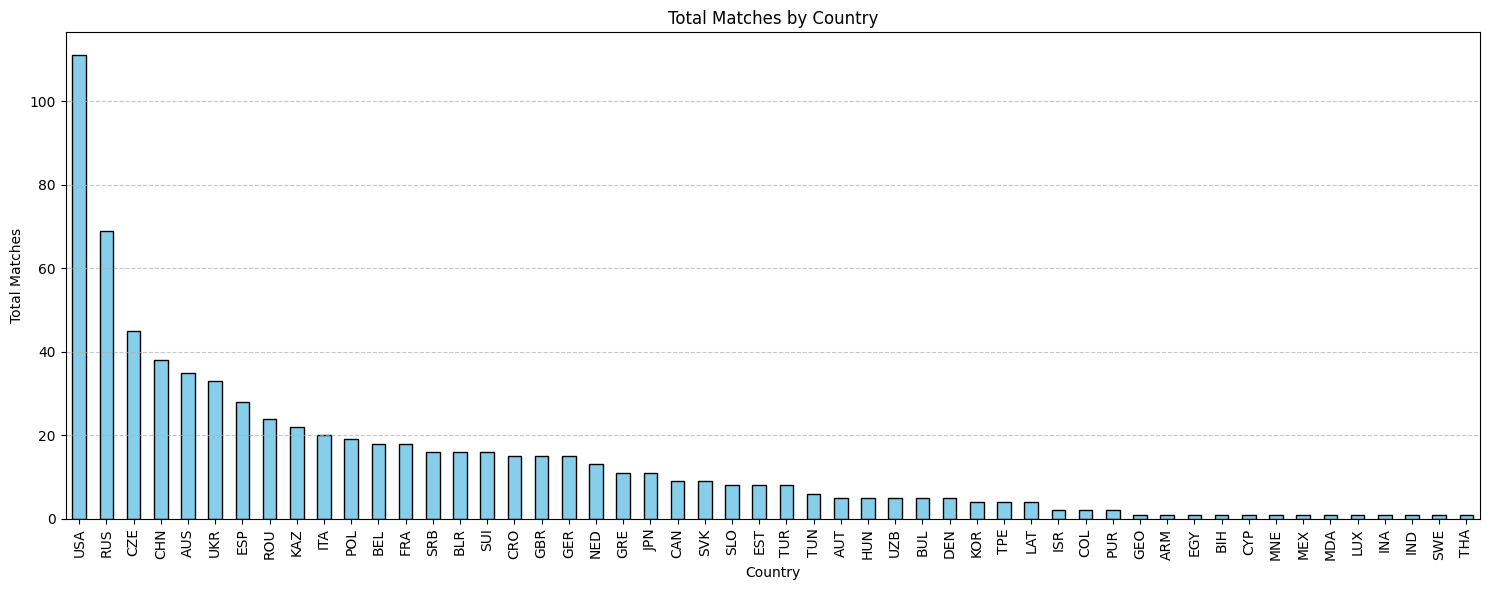

In [1455]:
plt.figure(figsize=(15, 6))
ax = group_by_country.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Matches by Country')
plt.xlabel('Country')
plt.ylabel('Total Matches')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [1456]:
group_by_surface = df.groupby('surface')['surface'].count().sort_values(ascending=False)

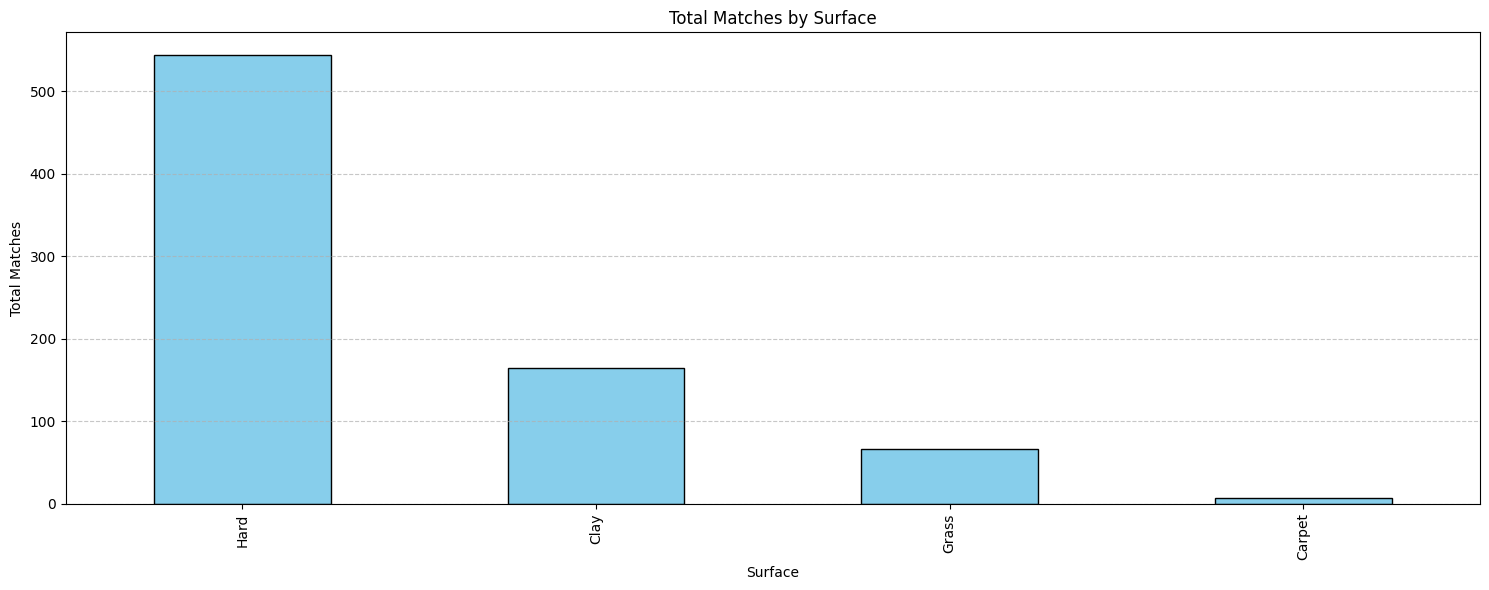

In [1457]:
plt.figure(figsize=(15, 6))
ax = group_by_surface.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Matches by Surface')
plt.xlabel('Surface')
plt.ylabel('Total Matches')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1458]:
import numpy

In [1459]:
df2 = pandas.DataFrame([{'firstname': 'Kendall', 'date': '4 - 15 Mar 2026'}])

In [1460]:
r = df2.loc[0].str.extract(r'^(\d+)\s?\-\s?(\d+)\s?(\w+)\s?(\d+)')
# r = df2.loc[0].str.extract(r'^(\d+)\s?(\w+)\s?\-\s?(\d+)\s?(\w+)\s?(\d+)')
pandas.notna(r[0].firstname)

False